We work with complex numbers when we introduce the Discrete Fourier Transform.

In [1]:
using Plots

To compute convolutions, we apply `conv` of the `DSP` package.

In [2]:
using DSP

# 1 Roots Of Unity

For example, consider the 8-th roots of unity.

In [3]:
n = 8

8

In [4]:
angle = 2*pi/8

0.7853981633974483

The imaginary unit in Julia is `im`.

In [5]:
omega = exp(angle*im)

0.7071067811865476 + 0.7071067811865475im

To verify that `omega` satiesfies indeed $x^8 - 1 = 0$, we compute

In [6]:
omega^8

1.0 - 8.881784197001252e-16im

Indeed, `omega` is a root of $x^8 - 1$ and there are seven others.

In [7]:
roots = [ omega^p for p=1:8 ]

8-element Vector{ComplexF64}:
     0.7071067811865476 + 0.7071067811865475im
  2.220446049250313e-16 + 1.0im
    -0.7071067811865474 + 0.7071067811865477im
                   -1.0 + 4.440892098500626e-16im
    -0.7071067811865479 - 0.7071067811865471im
 -6.661338147750939e-16 - 1.0im
      0.707106781186547 - 0.707106781186548im
                    1.0 - 8.881784197001252e-16im

Let us verify that each of the numbers in `roots` is indeed a root of $x^8 - 1$:

In [8]:
[r^8 for r in roots]

8-element Vector{ComplexF64}:
 1.0 - 8.881784197001252e-16im
 1.0 - 1.7763568394002505e-15im
 1.0 - 1.7763568394002505e-15im
 1.0 - 3.552713678800501e-15im
 1.0 - 4.440892098500626e-15im
 1.0 - 5.329070518200751e-15im
 1.0 - 5.551115123125783e-15im
 1.0 - 7.105427357601002e-15im

To plot the roots of unity, we separate real from imaginary parts in two separate arrays.

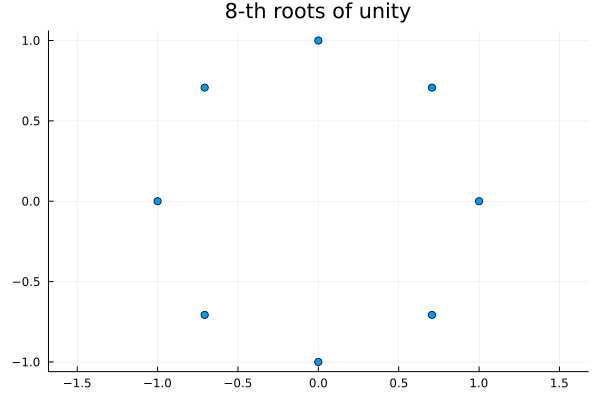

In [9]:
x = [root.re for root in roots]
y = [root.im for root in roots]
scatter(x, y, title="8-th roots of unity", legend=false, aspect_ratio=1)

# 2. Convolutions

Consider an input signal of the $\sin(2 \pi t)$ sampled at 8 Hertz.

In [10]:
u = [sin(2*pi*k/8) for k=0:7]

8-element Vector{Float64}:
  0.0
  0.7071067811865475
  1.0
  0.7071067811865476
  1.2246467991473532e-16
 -0.7071067811865475
 -1.0
 -0.7071067811865477

The transfer function of a filter which removes this signal is $1 + z^{-4}$, which the coefficients in `h`.

In [11]:
h = [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]

16-element Vector{Int64}:
 1
 0
 0
 0
 1
 0
 0
 0
 1
 0
 0
 0
 1
 0
 0
 0

In [12]:
y = conv(h, u)

23-element Vector{Float64}:
  0.0
  0.7071067811865475
  1.0
  0.7071067811865476
  1.2246467991473532e-16
  0.0
  0.0
 -1.1102230246251565e-16
  1.2246467991473532e-16
  0.0
  0.0
 -1.1102230246251565e-16
  1.2246467991473532e-16
  0.0
  0.0
 -1.1102230246251565e-16
  1.2246467991473532e-16
 -0.7071067811865475
 -1.0
 -0.7071067811865477
  0.0
  0.0
  0.0

Observe indeed the introduction of the zeros in the output `y`.